# Figure 9 — Cross-species comparison: behavioral states, Q-learning model, and state-conditioned behavior across reward-probability conditions

**NEW figure for the reviewer response — not part of the original manuscript, no legend to match against.** Panel layout agreed directly with the user:

- **a** — behavioral state proportions vs. reward probability of the better option, marmoset (80-20/90-10/100-0 Reversal task) vs. mouse (70-30/80-20/90-10, Beron et al. bandit data)
- **b** — sticky Q-learning + choice-kernel model parameters (alpha/beta/kappa), same axis, both species
- **c** — win-stay / lose-switch by behavioral state, same axis, both species
- **d** — raw single-trial switch rate by behavioral state, same axis, both species

Both species are classified with the **identical** `classify_state_updated_noAdapting` rule set
(`cross_species_comparison/run_pipeline.py`'s own verbatim port of
`09b_CrossProb_StickyModel_v1.ipynb`, lines 1798-1827) -- deliberately the
simpler 6-state space (`Exploitation`, `Directed Exploration`, `Random
Exploration`, `Left Bias`, `Right Bias`, `Unknown`), not this pipeline's
own 7-state `classify_state_v7` (which adds an Adapting fast/slow split
that was deliberately dropped for this specific cross-species comparison,
per an earlier standing decision -- mice don't have a validated
equivalent notion of block-transition adaptation speed in this dataset).
`Unknown` (NaN-feature rolling-window edge artifacts) is excluded from
every panel below -- not a real behavioral state.

Marmoset and mouse only share two conditions (80-20, 90-10); each species
also has one condition the other doesn't (marmoset's deterministic 100-0,
mouse's harder 70-30). Rather than force-align mismatched condition sets,
both are plotted on the same shared continuous x-axis -- reward
probability of the better option -- so the genuine overlap lines up
directly and each species' own extension is still visible.

Data: `cross_species_comparison/run_pipeline.py --thresholds marmoset`
(mouse side, already existing) and
`cross_species_comparison/run_pipeline_marmoset.py --thresholds marmoset`
(marmoset side, built for this figure -- see that script's own docstring
for why it's a separate, condition-generic script rather than reusing
`state_features.py`, which hardcodes the 80-20 condition's specific
probability values).

In [1]:
import os
import sys
import json

import pandas as pd
from IPython.display import SVG, display

sys.path.insert(0, os.path.abspath(".."))

from src.io.load_snapshots import load_config
from src.plotting.style import apply_style
from src.plotting import fig9 as plotting

config = load_config()
apply_style(config)
cfg = config["fig9"]

CROSS_SPECIES_DIR = os.path.normpath(os.path.join(os.path.abspath(".."), cfg["cross_species_dir"]))
THRESH_DIR = os.path.join(CROSS_SPECIES_DIR, "outputs", f"{cfg['threshold_set']}_thresholds")
print(f"Reading cross-species outputs from: {THRESH_DIR}")

FIG_DIR = os.path.join("..", config["paths"]["figures_out"], "Fig9")
os.makedirs(FIG_DIR, exist_ok=True)
MANIFEST_DIR = os.path.join("..", config["paths"]["values_manifests_out"])
os.makedirs(MANIFEST_DIR, exist_ok=True)

manifest = {"_stage": "Fig 9 -- cross-species comparison (marmoset vs. mouse), NEW figure for the reviewer response"}


def show(path):
    display(SVG(path))


def load(name):
    """Mouse-side files have no species prefix; marmoset-side files are
    prefixed marmoset_ (see run_pipeline_marmoset.py's own README note on
    why -- avoids colliding with the pre-existing unprefixed mouse files
    in the same outputs/<threshold_set>_thresholds/ directory)."""
    mouse = pd.read_csv(os.path.join(THRESH_DIR, f"{name}.csv"))
    marmoset = pd.read_csv(os.path.join(THRESH_DIR, f"marmoset_{name}.csv"))
    return marmoset, mouse

# Per-animal marmoset palette (config.yaml's plotting.animal_colors/animal_order --
# same one used throughout Fig1-Fig5 and fig8_3cond.py). Mice have no
# established per-individual color convention, so per-animal breakdowns
# below are marmoset-only.
ANIMAL_COLORS = config["plotting"]["animal_colors"]
ANIMAL_ORDER = config["plotting"]["animal_order"]

# Panels a/b already have a per-animal CSV precomputed by
# run_pipeline_marmoset.py. Panels c/d don't -- derived here directly from
# the raw classified trial data, mirroring that script's own aggregate
# switch-rate/win-stay-lose-switch cells exactly, just with an added
# per-animal split (see run_pipeline_marmoset.py's own cells for the
# un-split version this matches).
sys.path.insert(0, CROSS_SPECIES_DIR)
from run_pipeline import compute_win_stay_lose_switch  # noqa: E402

marmoset_classified = pd.read_csv(os.path.join(THRESH_DIR, "marmoset_df_classified.csv"), low_memory=False)
marmoset_classified = marmoset_classified[marmoset_classified["Behavioral_State"] != "Unknown"]

marmoset_switch_by_animal = (
    marmoset_classified.groupby(["prob_Condition", "Behavioral_State", "Animal_Name"])["PhysicalSwitch"]
    .agg(["mean", "count"]).rename(columns={"mean": "switch_rate", "count": "n_trials"})
    .reset_index().rename(columns={"prob_Condition": "Condition"})
)

# compute_win_stay_lose_switch only needs Mouse/Session renamed (same
# rename run_pipeline_marmoset.py itself uses, and the same reason it
# doesn't also rename prob_Condition -> Condition: the raw data already
# has its own unrelated Condition column).
df_for_wsls = marmoset_classified.rename(columns={"Animal_Name": "Mouse", "Session_ID": "Session"})
wsls_rows = []
for (cond, animal), adf in df_for_wsls.groupby(["prob_Condition", "Mouse"]):
    for state, sdf in adf.groupby("Behavioral_State"):
        if len(sdf) < 10:
            continue
        ws, ls, n_win, n_lose = compute_win_stay_lose_switch(sdf, adf)
        wsls_rows.append({
            "Condition": cond, "Animal_Name": animal, "Behavioral_State": state,
            "win_stay": ws, "lose_switch": ls,
            "n_win_trials": n_win, "n_lose_trials": n_lose, "n_trials": len(sdf),
        })
marmoset_wsls_by_animal = pd.DataFrame(wsls_rows)

print(f"Per-animal switch-rate rows: {len(marmoset_switch_by_animal)}; "
      f"per-animal win-stay/lose-switch rows: {len(marmoset_wsls_by_animal)}")

Reading cross-species outputs from: /Users/kevinmastro/Documents/Github/marmoset_decision_making/cross_species_comparison/outputs/marmoset_thresholds
Per-animal switch-rate rows: 94; per-animal win-stay/lose-switch rows: 91


## Panel a — state proportions

Excludes `Unknown`; states in a fixed order (`config.yaml`'s `fig9.states_order`) so panels are comparable across the figure.

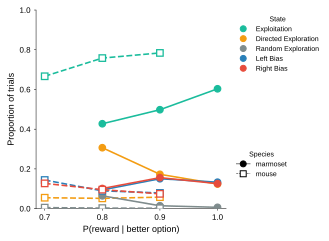

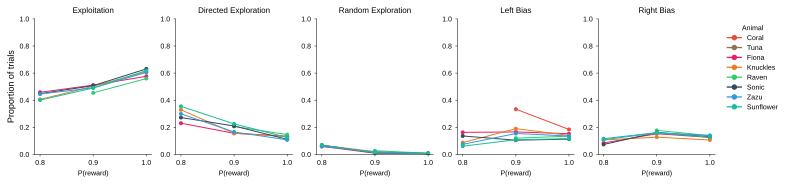

In [2]:
marmoset_prop, mouse_prop = load("state_proportions_by_condition")
marmoset_prop = marmoset_prop[marmoset_prop["Behavioral_State"] != "Unknown"]
mouse_prop = mouse_prop[mouse_prop["Behavioral_State"] != "Unknown"]

manifest["panel_a_marmoset_state_proportions"] = marmoset_prop.to_dict(orient="records")
manifest["panel_a_mouse_state_proportions"] = mouse_prop.to_dict(orient="records")

out_a = os.path.join(FIG_DIR, "Fig9a_state_proportions.svg")
plotting.plot_panel_a_state_proportions(marmoset_prop, mouse_prop, cfg, out_a)
show(out_a)

marmoset_prop_by_animal = pd.read_csv(os.path.join(THRESH_DIR, "marmoset_state_proportions_by_condition_and_animal.csv"))
marmoset_prop_by_animal = marmoset_prop_by_animal[marmoset_prop_by_animal["Behavioral_State"] != "Unknown"]
manifest["panel_a_marmoset_state_proportions_by_animal"] = marmoset_prop_by_animal.to_dict(orient="records")

out_a_animal = os.path.join(FIG_DIR, "Fig9a_marmoset_by_animal.svg")
plotting.plot_marmoset_per_animal_by_state(
    marmoset_prop_by_animal, cfg["states_order"], cfg["marmoset_conditions_order"], cfg["condition_to_prob"],
    "proportion", "Proportion of trials", ANIMAL_COLORS, ANIMAL_ORDER, out_a_animal, ylim=(0, 1.0),
)
show(out_a_animal)

## Panel b — sticky Q-learning + choice-kernel model parameters

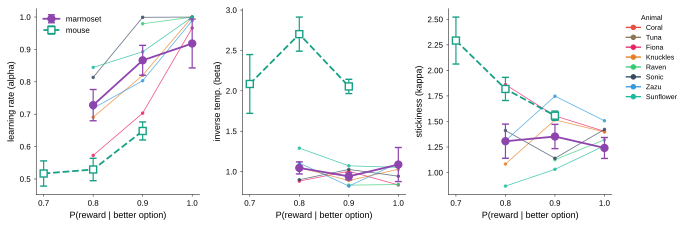

In [3]:
# Column names differ (Animal_Name vs. Mouse) but both scripts own
# per-subject fit tables are otherwise the same shape.
marmoset_fits = pd.read_csv(os.path.join(THRESH_DIR, "marmoset_sticky_model_params_by_animal_by_condition.csv"))
mouse_fits = pd.read_csv(os.path.join(THRESH_DIR, "sticky_model_params_by_mouse_by_condition.csv"))

def _flat_param_summary(fits):
    s = fits.groupby("Condition")[["alpha", "beta", "kappa"]].agg(["mean", "sem"])
    s.columns = [f"{param}_{stat}" for param, stat in s.columns]
    return s.reset_index().to_dict(orient="records")

manifest["panel_b_marmoset_param_summary"] = _flat_param_summary(marmoset_fits)
manifest["panel_b_mouse_param_summary"] = _flat_param_summary(mouse_fits)

out_b = os.path.join(FIG_DIR, "Fig9b_model_params.svg")
plotting.plot_panel_b_model_params(
    marmoset_fits, mouse_fits, cfg, out_b,
    marmoset_fits_by_animal=marmoset_fits, animal_colors=ANIMAL_COLORS, animal_order=ANIMAL_ORDER,
)
show(out_b)

## Panel c — win-stay / lose-switch by state

Watch Exploitation's lose-switch column: it stays low (~0.10-0.16) at the probabilistic conditions (80-20, 90-10, both species) but jumps to ~0.95 at marmoset's deterministic 100-0 -- consistent with a loss being a 100%-reliable "you picked wrong" signal only when reward is deterministic, unlike the probabilistic conditions where a single loss is often just noise.

Exploitation lose-switch by condition:
  marmoset: Condition  lose_switch
    100-0     0.947005
    80-20     0.101545
    90-10     0.157474
  mouse:    Condition  lose_switch
    70-30     0.092794
    80-20     0.117506
    90-10     0.233361


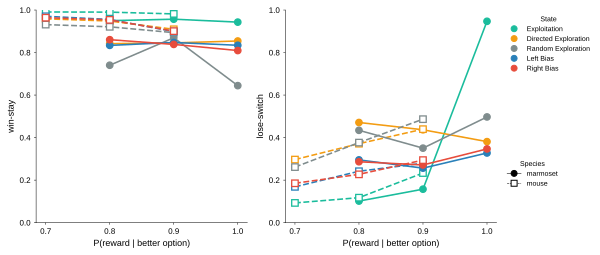

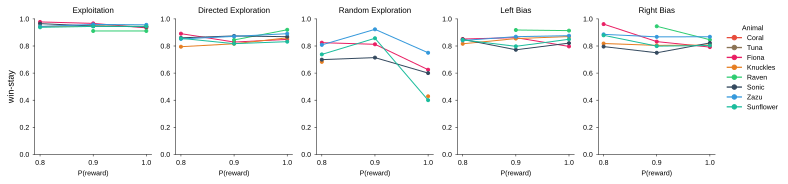

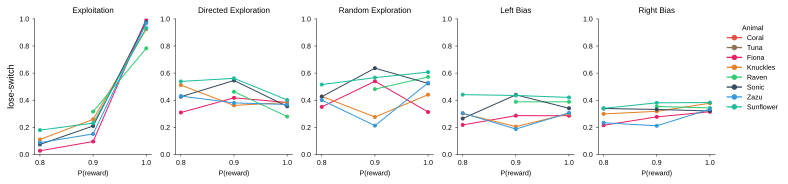

In [4]:
marmoset_wsls, mouse_wsls = load("winstay_loseswitch_by_state_by_condition")
marmoset_wsls = marmoset_wsls[marmoset_wsls["Behavioral_State"] != "Unknown"]
mouse_wsls = mouse_wsls[mouse_wsls["Behavioral_State"] != "Unknown"]

manifest["panel_c_marmoset_winstay_loseswitch"] = marmoset_wsls.to_dict(orient="records")
manifest["panel_c_mouse_winstay_loseswitch"] = mouse_wsls.to_dict(orient="records")

print("Exploitation lose-switch by condition:")
print("  marmoset:", marmoset_wsls[marmoset_wsls['Behavioral_State']=='Exploitation'][['Condition','lose_switch']].to_string(index=False))
print("  mouse:   ", mouse_wsls[mouse_wsls['Behavioral_State']=='Exploitation'][['Condition','lose_switch']].to_string(index=False))

out_c = os.path.join(FIG_DIR, "Fig9c_winstay_loseswitch.svg")
plotting.plot_panel_c_winstay_loseswitch(marmoset_wsls, mouse_wsls, cfg, out_c)
show(out_c)

manifest["panel_c_marmoset_winstay_loseswitch_by_animal"] = marmoset_wsls_by_animal.to_dict(orient="records")

out_c_ws_animal = os.path.join(FIG_DIR, "Fig9c_marmoset_by_animal_winstay.svg")
plotting.plot_marmoset_per_animal_by_state(
    marmoset_wsls_by_animal, cfg["states_order"], cfg["marmoset_conditions_order"], cfg["condition_to_prob"],
    "win_stay", "win-stay", ANIMAL_COLORS, ANIMAL_ORDER, out_c_ws_animal, ylim=(0, 1.0),
)
show(out_c_ws_animal)

out_c_ls_animal = os.path.join(FIG_DIR, "Fig9c_marmoset_by_animal_loseswitch.svg")
plotting.plot_marmoset_per_animal_by_state(
    marmoset_wsls_by_animal, cfg["states_order"], cfg["marmoset_conditions_order"], cfg["condition_to_prob"],
    "lose_switch", "lose-switch", ANIMAL_COLORS, ANIMAL_ORDER, out_c_ls_animal, ylim=(0, 1.0),
)
show(out_c_ls_animal)

## Panel d — switch rate by state

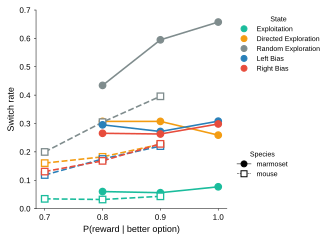

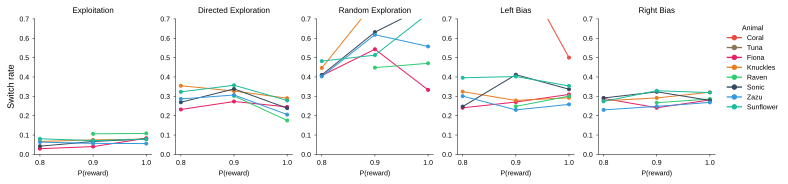

In [5]:
marmoset_switch, mouse_switch = load("switch_rate_by_state_by_condition")
marmoset_switch = marmoset_switch[marmoset_switch["Behavioral_State"] != "Unknown"]
mouse_switch = mouse_switch[mouse_switch["Behavioral_State"] != "Unknown"]

manifest["panel_d_marmoset_switch_rate"] = marmoset_switch.to_dict(orient="records")
manifest["panel_d_mouse_switch_rate"] = mouse_switch.to_dict(orient="records")

out_d = os.path.join(FIG_DIR, "Fig9d_switch_rate.svg")
plotting.plot_panel_d_switch_rate(marmoset_switch, mouse_switch, cfg, out_d)
show(out_d)

manifest["panel_d_marmoset_switch_rate_by_animal"] = marmoset_switch_by_animal.to_dict(orient="records")

out_d_animal = os.path.join(FIG_DIR, "Fig9d_marmoset_by_animal.svg")
plotting.plot_marmoset_per_animal_by_state(
    marmoset_switch_by_animal, cfg["states_order"], cfg["marmoset_conditions_order"], cfg["condition_to_prob"],
    "switch_rate", "Switch rate", ANIMAL_COLORS, ANIMAL_ORDER, out_d_animal, ylim=(0, 0.7),
)
show(out_d_animal)

## Values manifest

In [6]:
manifest_path = os.path.join(MANIFEST_DIR, "Fig9.json")
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2, default=str)
print(f"Saved values manifest: {manifest_path}")

Saved values manifest: ../outputs/values_manifests/Fig9.json
